# Stage 1: Building the Response Matrix H_tot

**Goal of this notebook**: build a matrix `H_tot` such that, for any
true runaway-electron (RE) energy distribution `x`, the detector would
measure `y = H_tot @ x` (plus noise).

**Recap of the physics chain**:

```
RE at true energy E  --[bremsstrahlung]-->  photon at energy k  --[detector]-->  recorded count at channel E
```

Two steps, two matrices:
- `H_e` : electron energy -> photon energy (Bethe-Heitler bremsstrahlung)
- `H_d` : photon energy -> detector channel (Gaussian detector resolution)
- `H_tot = H_d @ H_e` : the full chain


## Cell 1: Setup and energy grid

We define 100 energy bins from 0 to 15 MeV. The SAME grid is used for
true electron energy, photon energy, and detector channel energy --
this keeps every matrix square (100X100) and avoids index confusion.

**Check after running**: bin width should print as 0.150 MeV
(15 MeV / 100 bins).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N_BINS = 100
E_MIN = 0.0   # MeV
E_MAX = 15.0  # MeV

E_EDGES = np.linspace(E_MIN, E_MAX, N_BINS + 1)
E_CENTERS = 0.5 * (E_EDGES[:-1] + E_EDGES[1:])        # avg of  left and right edges
DE = E_EDGES[1] - E_EDGES[0]        # bin width

print(f"Number of bins: {N_BINS}")
print(f"Bin width: {DE:.3f} MeV")
print(f"First few bin centers: {E_CENTERS[:5]} MeV")
print(f"Last bin center: {E_CENTERS[-1]:.3f} MeV")


Number of bins: 100
Bin width: 0.150 MeV
First few bin centers: [0.075 0.225 0.375 0.525 0.675] MeV
Last bin center: 14.925 MeV


## Cell 2: H_e -- electron -> photon (Bethe-Heitler)

**Physics being encoded**: a single electron of energy `E` produces a
*range* of possible photon energies `k`, with three facts baked in:

1. `k` can never exceed `E` (a photon can't carry more energy than the
   electron that made it) -> hard cutoff
2. Low-energy ("soft") photons are much more likely -> the `1/k` term
3. The probability tapers toward zero as `k -> E`

We use the simplified shape `dN/dk ~ (1/k) * (1 - x + 0.75*x^2)` where
`x = k/E`, for `0 < k < E`.

**Each column of H_e is normalized to sum to 1** -- i.e. for one fixed
electron energy, "where does its photon energy go" is a probability
distribution.

**Check after running**: `H_e column sums` should print all 1.0000.

In [3]:
def bethe_heitler_spectrum(E_electron, k_array):
    """dN/dk (un-normalized), zero for k<=0 or k>=E_electron."""
    spectrum = np.zeros_like(k_array)
    valid = (k_array > 0) & (k_array < E_electron)
    k = k_array[valid]
    x = k / E_electron
    spectrum[valid] = (1.0 / k) * (1.0 - x + 0.75 * x**2)
    return spectrum


def build_H_e(E_centers):
    n = len(E_centers)
    H_e = np.zeros((n, n))
    for i, E_electron in enumerate(E_centers):
        spectrum = bethe_heitler_spectrum(E_electron, E_centers)
        total = spectrum.sum()
        if total > 0:
            H_e[:, i] = spectrum / total
        else:
            # electron too low-energy to make a photon on our grid
            H_e[0, i] = 1.0
    return H_e


H_e = build_H_e(E_CENTERS)

print(f"H_e shape: {H_e.shape}")
print(f"H_e column sums (min, max): {H_e.sum(axis=0).min():.4f}, {H_e.sum(axis=0).max():.4f}")


H_e shape: (100, 100)
H_e column sums (min, max): 1.0000, 1.0000


## Cell 3: Visualize H_e columns

This is the most important plot for understanding H_e. Each line shows:
"if I have ONE electron at energy X, what's the probability distribution
of the photon it produces?"

**What to check**: each curve should sharply cut to zero AT its own
electron energy (the 1.9 MeV curve hits zero at k=1.9, the 5.8 MeV
curve at k=5.8, etc.) -- that's the "photon can't exceed electron
energy" rule from the physics.

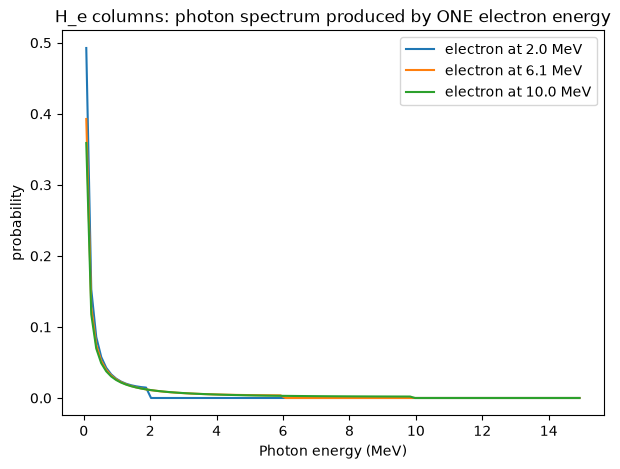

In [4]:
plt.figure(figsize=(7, 5))
for E_test in [2, 6, 10]:
    i_idx = np.argmin(np.abs(E_CENTERS - E_test))
    plt.plot(E_CENTERS, H_e[:, i_idx], label=f"electron at {E_CENTERS[i_idx]:.1f} MeV")
plt.xlabel("Photon energy (MeV)")
plt.ylabel("probability")
plt.title("H_e columns: photon spectrum produced by ONE electron energy")
plt.legend()
plt.show()


## Cell 4: H_d -- photon -> detector channel (Gaussian resolution)

**Physics being encoded**: a monoenergetic photon doesn't get recorded
in one exact channel -- the detector spreads it into a Gaussian, with
a width (FWHM) that grows with energy:

```
FWHM(E) = a + b*sqrt(E) + c*E^2
```

`a, b, c` are PLACEHOLDER values (same ballpark as the NaI(Tl) detector
in the papers, ~11.5% resolution at 0.6616 MeV). These should eventually
be replaced with ADITYA-U's actual detector values.

**Each column of H_d is normalized to sum to 1** -- "for one photon
energy, where does it land in the detector" is a probability
distribution.

**Check after running**: `H_d column sums` should print all 1.0000.

# Placeholder resolution parameters (MeV, MeV^0.5, 1/MeV)
A_RES = 0.03
B_RES = 0.05
C_RES = 0.001

FWHM_TO_SIGMA = 1.0 / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def fwhm_at_energy(E):
    fwhm = A_RES + B_RES * np.sqrt(np.abs(E)) + C_RES * E**2
    return np.maximum(fwhm, 0.01)  # floor so FWHM never hits 0

def build_H_d(E_centers):
    n = len(E_centers)
    H_d = np.zeros((n, n))
    for k_idx, E_photon in enumerate(E_centers):
        sigma = fwhm_at_energy(E_photon) * FWHM_TO_SIGMA
        gauss = np.exp(-0.5 * ((E_centers - E_photon) / sigma) ** 2)
        H_d[:, k_idx] = gauss / gauss.sum()
    return H_d

H_d = build_H_d(E_CENTERS)

print(f"H_d shape: {H_d.shape}")
print(f"H_d column sums (min, max): {H_d.sum(axis=0).min():.4f}, {H_d.sum(axis=0).max():.4f}")


## Cell 5: Visualize H_d columns

**What to check**: each curve should be a clean bell shape (Gaussian),
centered at its own photon energy, and the HIGHER-energy curves should
be visibly WIDER than the lower-energy ones (resolution gets worse at
higher energy -- that's the `+ c*E^2` term).

In [5]:
plt.figure(figsize=(7, 5))
for E_test in [2, 6, 10]:
    k_idx = np.argmin(np.abs(E_CENTERS - E_test))
    plt.plot(E_CENTERS, H_d[:, k_idx], label=f"photon at {E_CENTERS[k_idx]:.1f} MeV")
plt.xlabel("Detector channel energy (MeV)")
plt.ylabel("probability")
plt.title("H_d columns: detector response to ONE photon energy")
plt.legend()
plt.show()


NameError: name 'H_d' is not defined

<Figure size 700x500 with 0 Axes>

## Cell 6: Combine -- H_tot = H_d @ H_e

This is the matrix multiplication that chains the two steps together
(composition of two linear operators -- summing over the intermediate photon energy).

**Check after running**: `H_tot column sums` should print all ~1.0000.

In [ ]:
H_tot = H_d @ H_e

print(f"H_tot shape: {H_tot.shape}")
print(f"H_tot column sums (min, max): {H_tot.sum(axis=0).min():.4f}, {H_tot.sum(axis=0).max():.4f}")


H_tot shape: (100, 100)
H_tot column sums (min, max): 1.0000, 1.0000


## Cell 7: Visualize H_tot columns -- THE IMPORTANT CHECK

Each curve shows: "if I have ONE electron at energy X, what does the
FULL chain (bremsstrahlung + detector) produce as a measured spectrum?"

**This is the check that matters for MLEM**: compare the three curves
(2, 6, 10 MeV electrons). 

- If they look like DIFFERENT shapes (e.g. peak position or shape
  clearly shifts with electron energy) -> good, MLEM will be able to
  tell these electron energies apart.
- If they look like basically the SAME shape just scaled up/down ->
  problem. It means the response matrix can't distinguish a 2 MeV
  electron from a 10 MeV electron, and MLEM would have no way to
  recover which one actually produced a given measurement.

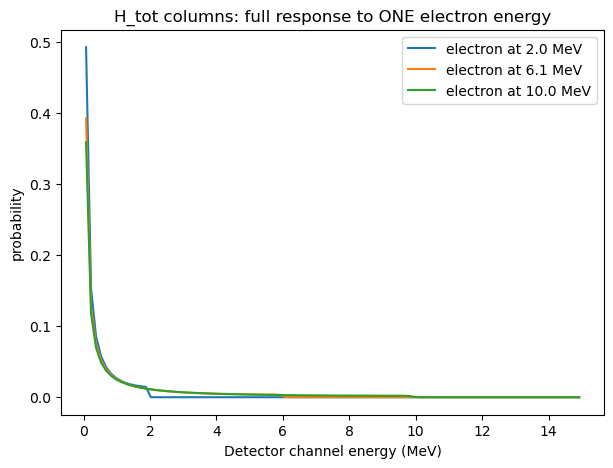

In [ ]:
plt.figure(figsize=(7, 5))
for E_test in [2, 6, 10]:
    i_idx = np.argmin(np.abs(E_CENTERS - E_test))
    plt.plot(E_CENTERS, H_tot[:, i_idx], label=f"electron at {E_CENTERS[i_idx]:.1f} MeV")
plt.xlabel("Detector channel energy (MeV)")
plt.ylabel("probability")
plt.title("H_tot columns: full response to ONE electron energy")
plt.legend()
plt.show()


## Cell 8: Save matrices for later stages

Saves `H_e`, `H_d`, `H_tot`, and the energy grid to a `.npz` file.

In [ ]:
np.savez("response_matrices.npz",
         E_centers=E_CENTERS,
         E_edges=E_EDGES,
         H_e=H_e,
         H_d=H_d,
         H_tot=H_tot)

print("Saved to response_matrices.npz")


Saved to response_matrices.npz
